# Explore

## Setup

In [1]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
import chonknoris
from util import get_torch_device_backend
import os
import numpy as np 
import torch 
torch.set_default_dtype(torch.float64)

In [2]:
DEVICE,TORCH_BACKEND = get_torch_device_backend()
DEVICE

device(type='cuda', index=0)

In [3]:
from matplotlib import pyplot,colors,cm,cycler
import pandas as pd
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)

## Load Data

In [4]:
pname = "RES14"
vtype = "Style_B"
OUTDIR = "data/%s/%s"%(pname,vtype)
print("datasets")
datasets = {}
for f in os.listdir(OUTDIR):
    if f[:3]!="NK." or f[-3:]!=".pt" or f in []:
        continue 
    print("\t%s"%f)
    datasets[f] = torch.load("%s/%s"%(OUTDIR,f),weights_only=True)
dskeys = list(datasets.keys())

datasets
	NK.NEWTRY_RELAX_1e+01.RKHS_v_eye.RKHS_w_eye.pt


## Plot

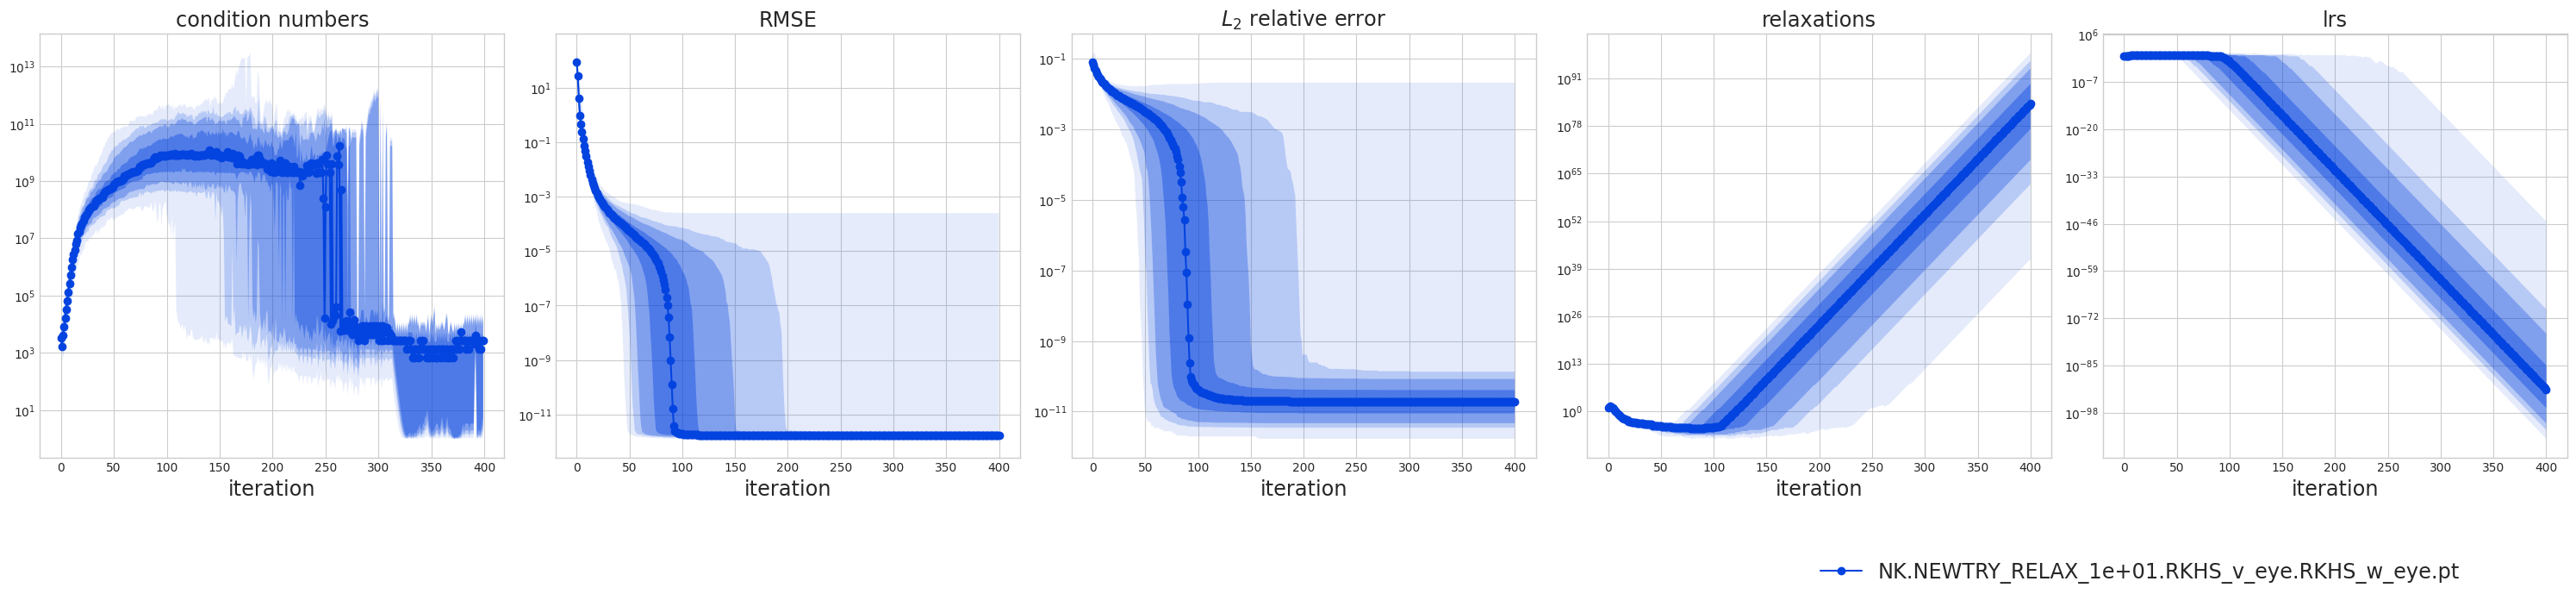

In [5]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["cond_nums"],k) for k,data in datasets.items()],
            [(None,data["rmses"],k) for k,data in datasets.items()],
            [(None,data["l2rerrors"],k) for k,data in datasets.items()],
            [(None,data["relaxations"],k) for k,data in datasets.items()],
            [(None,data["lrs"],k) for k,data in datasets.items()],
        ],
    ],
    sharex = False,
    titles = [["condition numbers","RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None,None]],
    xlabels = "iteration",#[["iteration"],["time [sec]"]],
    xlogscale = False,
    # colors = COLORS,#[COLORS[0]],
    ylogscale = True,
    #qlows = [.80],
    #qhighs = [.20],
    fsx=6,fsy=6,
    use_nan_funcs=True,
    legends=False)
ax[0,0].legend(bbox_to_anchor=(5.25,-.2),ncol=4,fontsize="xx-large");
# fig.tight_layout()
# fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

vvs.shape = (4, 14, 14)
vref.shape = (14, 14)


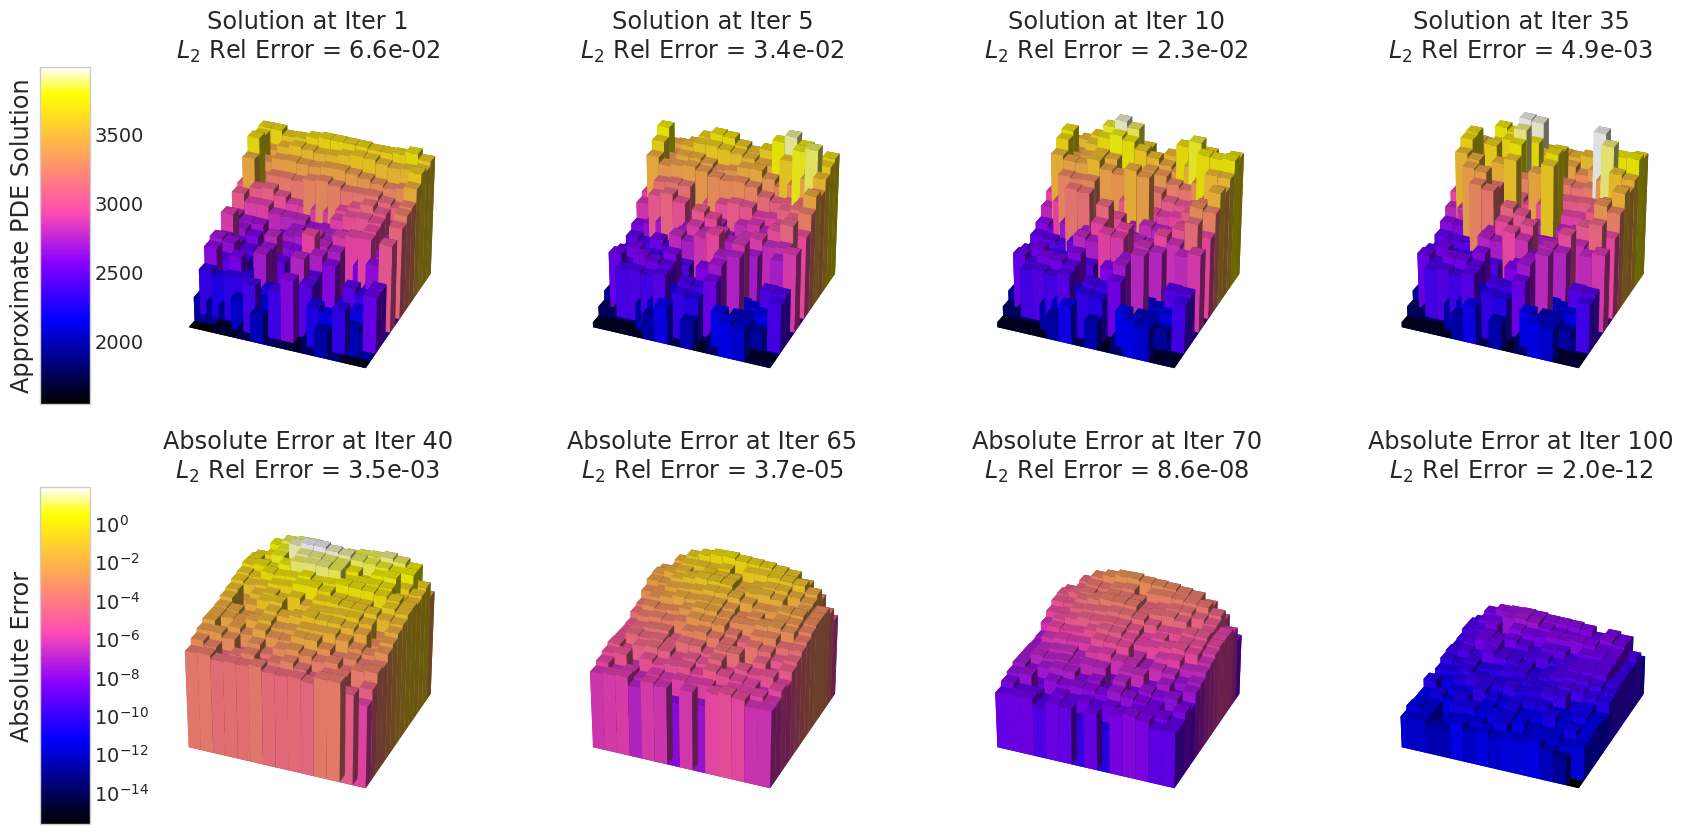

In [6]:
_ds = datasets["NK.NEWTRY_RELAX_1e+01.RKHS_v_eye.RKHS_w_eye.pt"]
r = 0
iters = [1,5,10,35]
iters_error = [40,65,70,100]
v = _ds["vs"][r,iters]
vmin,vmax = v.min(),v.max()
vnorm = pyplot.Normalize(vmin=vmin,vmax=vmax)
vref = _ds["v_true"][r]
v4error = _ds["vs"][r,iters_error]
error = torch.maximum(torch.abs(v4error-vref),torch.finfo(torch.float64).eps*torch.ones(1))
l2rerror = torch.linalg.norm(torch.abs(v-vref).flatten(start_dim=1),dim=1)/torch.linalg.norm(vref)
l2rerror_error = torch.linalg.norm(torch.abs(v4error-vref).flatten(start_dim=1),dim=1)/torch.linalg.norm(vref)
log10error = torch.log10(error) 
log10errormin,log10errormax = log10error.min(),log10error.max()
log10errornorm = pyplot.Normalize(vmin=log10errormin,vmax=log10errormax)
print("vvs.shape = %s"%str(tuple(v.shape)))
print("vref.shape = %s"%str(tuple(vref.shape)))
nrows = 2 
ncols = len(iters)
plot_type = "bar3d"
# cmap = pyplot.cm.gnuplot
cmap = pyplot.cm.gnuplot2
i1mesh,i0mesh = torch.meshgrid(torch.arange(vref.shape[-1]),torch.arange(vref.shape[-1]),indexing="ij")
fig = pyplot.figure(figsize=(5*ncols,5*nrows))
ax = np.array([[fig.add_subplot(nrows,ncols,i*ncols+j+1,projection="3d" if plot_type in ["bar3d","plot_surface"] else None) for j in range(ncols)] for i in range(nrows)]).reshape((nrows,ncols))
for i in range(ncols):
    if plot_type=="bar3d":
        bar3dops = {"zsort":"min","shade":True}
        colorsv = cmap(vnorm(v[i].flatten()))
        ax[0,i].bar3d(i0mesh.flatten(),i1mesh.flatten(),vmin,1,1,v[i].flatten()-vmin,color=colorsv,**bar3dops)
        ax[0,i].set_zlim(vmin,vmax)
        colorserror = cmap(log10errornorm(log10error[i].flatten()))
        #ax[1,i].bar3d(i0mesh.flatten(),i1mesh.flatten(),log10error[i].min(),1,1,log10error[i].flatten()-log10error[i].min(),color=colorserror,**bar3dops)
        ax[1,i].bar3d(i0mesh.flatten(),i1mesh.flatten(),log10errormin,1,1,log10error[i].flatten()-log10errormin,color=colorserror,**bar3dops)
        ax[1,i].set_zlim(log10errormin,log10errormax)
    elif plot_type=="plot_surface":
        ax[0,i].plot_surface(i0mesh,i1mesh,v[i],cmap=cmap)
        ax[1,i].plot_surface(i0mesh,i1mesh,torch.log10(error[i]),cmap=cmap)
    elif plot_type=="contourf":
        ax[0,i].contourf(i0mesh,i1mesh,v[i],cmap=cmap,levels=100)
        ax[1,i].contourf(i0mesh,i1mesh,torch.log10(error[i]),cmap=cmap,levels=32)
    else:
        assert False, "invalid plot_type"
    if plot_type in ["bar3d","plot_surface"]:
        for j in range(2):
            ax[j,i].view_init(None,(-45-90)/2)
            ax[j,i].set_axis_off()
            ax[j,i].grid(False)
            ax[j,i].xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax[j,i].yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax[j,i].zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax[j,i].xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
            ax[j,i].yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
            ax[j,i].zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
    ax[0,i].set_title("Solution at Iter %d\n$L_2$ Rel Error = %.1e"%(iters[i],l2rerror[i]),fontsize="xx-large")
    ax[1,i].set_title("Absolute Error at Iter %d\n$L_2$ Rel Error = %.1e"%(iters_error[i],l2rerror_error[i]),fontsize="xx-large")
    # ax[1,i].set_title(r"$L_2$ relative error = %.1e"%l2rerror[i],fontsize="xx-large")
    # ax[1,i].set_zscale("log",base=10)
cax_v = fig.add_axes([ax[0,0].get_position().x0-.05,ax[0,0].get_position().y0,0.025,ax[0,0].get_position().y1-ax[0,0].get_position().y0])
cbar_v = fig.colorbar(cm.ScalarMappable(norm=vnorm,cmap=cmap),cax_v,location="left")
cbar_v.ax.yaxis.set_ticks_position('right')
cbar_v.ax.tick_params(labelsize=14)
cbar_v.set_label("Approximate PDE Solution",fontsize="xx-large")
cax_error = fig.add_axes([ax[1,0].get_position().x0-.05,ax[1,0].get_position().y0,0.025,ax[1,0].get_position().y1-ax[1,0].get_position().y0])
cax_error = fig.colorbar(cm.ScalarMappable(norm=log10errornorm,cmap=cmap),cax_error,location="left")
cax_error.ax.yaxis.set_ticks_position('right')
curr_ticks = torch.floor(torch.tensor(cax_error.ax.get_yticks())[1:-1]).to(int)
cax_error.ax.set_yticks(curr_ticks)
cax_error.ax.set_yticklabels([r"$10^{%d}$"%curr_tick for curr_tick in curr_ticks])
cax_error.ax.tick_params(labelsize=14)
cax_error.set_label("Absolute Error",fontsize="xx-large")
fig.savefig("nk_fwi_viz.pdf",bbox_inches="tight")
# fig.tight_layout()

In [7]:
datasets = {
    r"$5 \times 5$ resolution": torch.load("./data/RES5/Style_B/CHONKNORIS.GP.SAVE.RES5.Style_B.pt",weights_only=True),
    r"$7 \times 7$ resolution": torch.load("./data/RES7/Style_B/CHONKNORIS.GP.SAVE.RES7.Style_B.pt",weights_only=True),
    r"$10 \times 10$ resolution": torch.load("./data/RES10/Style_B/CHONKNORIS.GP.SAVE.RES10.Style_B.pt",weights_only=True),
}
dskeys = list(datasets.keys())
for key in dskeys:
    datasets[key]["relaxations"][:,1:][~datasets[key]["updated"]] = torch.nan
    datasets[key]["lrs"][:,1:][~datasets[key]["updated"]] = torch.nan
for name in dskeys:
    ds = datasets[name]
    print(name)
    for k,v in ds.items():
        print("\t%s.shape = %s"%(k,str(tuple(v.shape))))

$5 \times 5$ resolution
	vs.shape = (25, 101, 5, 5)
	rmses.shape = (25, 101)
	times.shape = (101,)
	relaxations.shape = (25, 101)
	lrs.shape = (25, 101)
	updated.shape = (25, 100)
	l2rerrors.shape = (25, 101)
$7 \times 7$ resolution
	vs.shape = (25, 2501, 7, 7)
	rmses.shape = (25, 2501)
	times.shape = (2501,)
	relaxations.shape = (25, 2501)
	lrs.shape = (25, 2501)
	updated.shape = (25, 2500)
	l2rerrors.shape = (25, 2501)
$10 \times 10$ resolution
	vs.shape = (25, 25001, 10, 10)
	rmses.shape = (25, 25001)
	times.shape = (25001,)
	relaxations.shape = (25, 25001)
	lrs.shape = (25, 25001)
	updated.shape = (25, 25000)
	l2rerrors.shape = (25, 25001)


In [8]:
datasets_ref = {
    r"$5 \times 5$ resolution": torch.load("./data/RES5/Style_B/NK.NEWTRY_RELAX_1e+01.RKHS_v_eye.RKHS_w_eye.pt",weights_only=True),
    r"$7 \times 7$ resolution": torch.load("./data/RES7/Style_B/NK.NEWTRY_RELAX_1e+01.RKHS_v_eye.RKHS_w_eye.pt",weights_only=True),
    r"$10 \times 10$ resolution": torch.load("./data/RES10/Style_B/NK.NEWTRY_RELAX_1e+01.RKHS_v_eye.RKHS_w_eye.pt",weights_only=True),
    r"$14 \times 14$ resolution": torch.load("./data/RES14/Style_B/NK.NEWTRY_RELAX_1e+01.RKHS_v_eye.RKHS_w_eye.pt",weights_only=True),
}
dskeys_ref = list(datasets_ref.keys())
for key in dskeys_ref:
    datasets_ref[key]["relaxations"][:,1:][~datasets_ref[key]["updated"]] = torch.nan
    datasets_ref[key]["lrs"][:,1:][~datasets_ref[key]["updated"]] = torch.nan
for name in dskeys_ref:
    ds = datasets_ref[name]
    print(name)
    for k,v in ds.items():
        print("\t%s.shape = %s"%(k,str(tuple(v.shape))))

$5 \times 5$ resolution
	vs.shape = (1000, 401, 5, 5)
	rmses.shape = (1000, 401)
	times.shape = (401,)
	relaxations.shape = (1000, 401)
	lrs.shape = (1000, 401)
	updated.shape = (1000, 400)
	Linvs.shape = (1000, 400, 25, 25)
	cond_nums.shape = (1000, 400)
	l2rerrors.shape = (1000, 401)
	v_true.shape = (1000, 5, 5)
	w_true.shape = (1000, 5, 71, 5)
$7 \times 7$ resolution
	vs.shape = (1000, 401, 7, 7)
	rmses.shape = (1000, 401)
	times.shape = (401,)
	relaxations.shape = (1000, 401)
	lrs.shape = (1000, 401)
	updated.shape = (1000, 400)
	Linvs.shape = (1000, 400, 49, 49)
	cond_nums.shape = (1000, 400)
	l2rerrors.shape = (1000, 401)
	v_true.shape = (1000, 7, 7)
	w_true.shape = (1000, 5, 100, 7)
$10 \times 10$ resolution
	vs.shape = (1000, 401, 10, 10)
	rmses.shape = (1000, 401)
	times.shape = (401,)
	relaxations.shape = (1000, 401)
	lrs.shape = (1000, 401)
	updated.shape = (1000, 400)
	Linvs.shape = (1000, 400, 100, 100)
	cond_nums.shape = (1000, 400)
	l2rerrors.shape = (1000, 401)
	v_true.

In [14]:
metrics = [
    #"relaxations",
    "cond_nums",
    "l2rerrors",
]
dstore_ref = {
     "dskeys_ref": dskeys_ref,
     "metrics": metrics,
}
qllf,qlf,qhf,qhhf = .1,.25,.75,.9
for j,name in enumerate(dskeys_ref):
    dstore_ref[name] = {}
    for l,metric in enumerate(metrics):
        qll = torch.nanquantile(datasets_ref[name][metric],q=qllf,dim=0)
        ql = torch.nanquantile(datasets_ref[name][metric],q=qlf,dim=0)
        qmed = torch.nanquantile(datasets_ref[name][metric],q=.5,dim=0)
        qh = torch.nanquantile(datasets_ref[name][metric],q=qhf,dim=0)
        qhh = torch.nanquantile(datasets_ref[name][metric],q=qhhf,dim=0)
        dstore_ref[name][metric] = (qll,ql,qmed,qh,qhh)
metrics = ["l2rerrors"]
dstore_chonknoris = {
     "dskeys": dskeys,
     "metrics": metrics,
}
for j,name in enumerate(dskeys):
    dstore_chonknoris[name] = {}
    for l,metric in enumerate(metrics):
        qll = torch.nanquantile(datasets[name][metric],q=qllf,dim=0)
        ql = torch.nanquantile(datasets[name][metric],q=qlf,dim=0)
        qmed = torch.nanquantile(datasets[name]["l2rerrors"],q=.5,dim=0)
        qh = torch.nanquantile(datasets[name][metric],q=qhf,dim=0)
        qhh = torch.nanquantile(datasets[name][metric],q=qhhf,dim=0)
        dstore_chonknoris[name][metric] = (qll,ql,qmed,qh,qhh)
    dstore_chonknoris[name]['times'] = datasets[name]['times'].cumsum(0)/datasets[name][metric].size(0)
torch.save(
    {
        "data_ref": dstore_ref,
        "data_chonknoris": dstore_chonknoris,
        "vs": datasets["$7 \\times 7$ resolution"]["vs"],
        "vs_l2rerrors": datasets["$7 \\times 7$ resolution"]["l2rerrors"],
    },
    "data_final_plot.seismic_imaging.pt")